# Extra Analysis: Practical Significance

This notebook provides an extra analysis for Project Cycle 3.

The main inference result showed that the difference in current alcohol use between male and female students was not statistically significant. In this extra analysis, we examine the practical size of the difference using the difference in proportions and relative risk.

This extra analysis supports the main conclusion but does not replace the two-proportion z-test.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

project_dir = Path("..")

processed_data_path = project_dir / "data" / "processed" / "cycle3_cleaned_alcohol_gender.csv"
figures_dir = project_dir / "outputs" / "figures"
tables_dir = project_dir / "outputs" / "tables"

figures_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(processed_data_path)

df.head()

,sex_group,current_alcohol_use
0,Female,0
1,Female,0
2,Female,0
3,Female,0
4,Female,0


In [2]:
group_summary = df.groupby("sex_group").agg(
    sample_size=("current_alcohol_use", "count"),
    alcohol_users=("current_alcohol_use", "sum"),
    alcohol_use_proportion=("current_alcohol_use", "mean")
)

female_prop = group_summary.loc["Female", "alcohol_use_proportion"]
male_prop = group_summary.loc["Male", "alcohol_use_proportion"]

difference = male_prop - female_prop
relative_risk = male_prop / female_prop

effect_size_table = pd.DataFrame({
    "Measure": [
        "Female alcohol use proportion",
        "Male alcohol use proportion",
        "Difference in proportions (Male - Female)",
        "Relative risk (Male / Female)"
    ],
    "Value": [
        female_prop,
        male_prop,
        difference,
        relative_risk
    ]
})

effect_size_table

,Measure,Value
0,Female alcohol use proportion,0.445759
1,Male alcohol use proportion,0.457652
2,Difference in proportions (Male - Female),0.011893
3,Relative risk (Male / Female),1.026680


In [3]:
effect_size_table.to_csv(
    tables_dir / "effect_size_table_alcohol_by_gender.csv",
    index=False
)

print("Effect size table saved.")

Effect size table saved.


In [4]:
proportion_table = pd.crosstab(
    df["sex_group"],
    df["current_alcohol_use"],
    normalize="index"
) * 100

proportion_table.columns = [
    "Did not currently use alcohol",
    "Currently used alcohol"
]

proportion_table

,Did not currently use alcohol,Currently used alcohol
sex_group,,
Female,55.424125,44.575875
Male,54.234841,45.765159


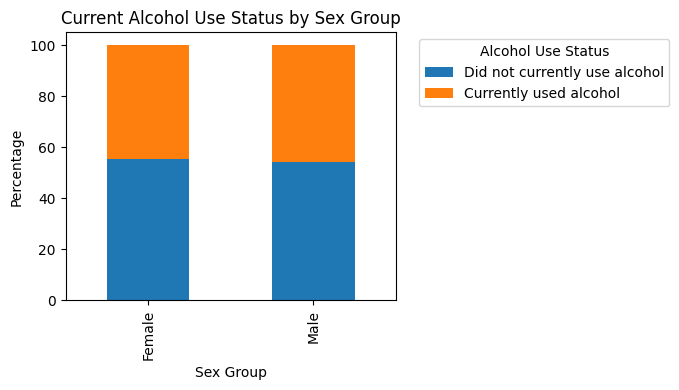

In [5]:
proportion_table.plot(
    kind="bar",
    stacked=True,
    figsize=(7, 4)
)

plt.xlabel("Sex Group")
plt.ylabel("Percentage")
plt.title("Current Alcohol Use Status by Sex Group")
plt.legend(
    title="Alcohol Use Status",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.savefig(
    figures_dir / "stacked_bar_alcohol_status_by_gender.png",
    dpi=300
)
plt.show()

## Extra Analysis Interpretation

The male alcohol use proportion was slightly higher than the female alcohol use proportion.

The estimated difference was about 0.0119, meaning that male students had about 1.19 percentage points higher current alcohol use than female students in this sample.

The relative risk was about 1.03. This means that the current alcohol use proportion for male students was about 1.03 times the proportion for female students.

This difference is small in practical size. Together with the main two-proportion z-test result, this supports the conclusion that there is not strong evidence of a meaningful difference in current alcohol use between male and female students.

The stacked bar chart also shows that the alcohol use distributions of female and male students are very similar.